In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import urllib.request, os

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
if not os.path.exists("mnist.npz"):
    urllib.request.urlretrieve(url, "mnist.npz")

data = np.load("mnist.npz")
X_train, y_train = data["x_train"], data["y_train"]
X_test, y_test = data["x_test"], data["y_test"]

In [5]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


5


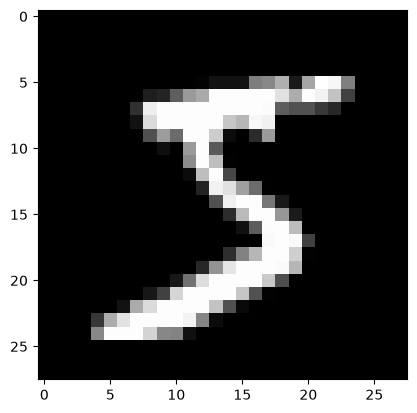

In [6]:
print(y_train[0])
plt.imshow(X_train[0], cmap="gray")
plt.show()

In [7]:
print(X_train[0])
print(X_train.min(), X_train.max())

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

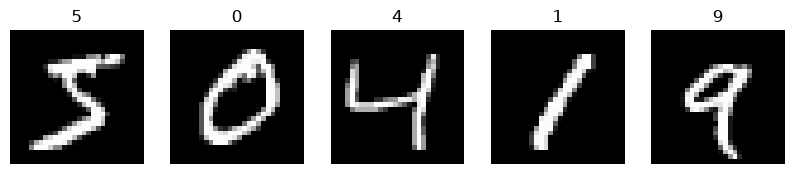

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    axes[i].imshow(X_train[i], cmap="gray")
    axes[i].set_title(y_train[i])
    axes[i].axis("off")

plt.show()

In [9]:
# 1. Flatten: each 28x28 image becomes one row of 784 numbers
# 2. Normalize: pixel values go from 0-255 down to 0-1
X_train_flat = X_train.reshape(60000, 784) / 255.0
X_test_flat = X_test.reshape(10000, 784) / 255.0


In [10]:

# 3. One-hot encode the training labels
Y_train = np.eye(10)[y_train]

In [11]:
# Check the results
print(X_train_flat.shape)                      # (60000, 784)
print(X_test_flat.shape)                       # (10000, 784)
print(X_train_flat.min(), X_train_flat.max())  # 0.0 1.0
print(Y_train.shape)                           # (60000, 10)
print(y_train[0], Y_train[0])                  # 5 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

(60000, 784)
(10000, 784)
0.0 1.0
(60000, 10)
5 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [12]:
np.random.seed(42)  # makes the random numbers the same every run

def init_params():
    W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
    b1 = np.zeros((1, 128))
    W2 = np.random.randn(128, 10) * np.sqrt(2 / 128)
    b2 = np.zeros((1, 10))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()

print(W1.shape, b1.shape, W2.shape, b2.shape)

(784, 128) (1, 128) (128, 10) (1, 10)


In [14]:
def relu(z):
    return np.maximum(0, z)


def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    return Z1, A1, A2


# Test on the first 5 images
Z1, A1, A2 = forward(X_train_flat[:5], W1, b1, W2, b2)
print(A1.shape, A2.shape)   # (5, 128) (5, 10)
print(A2.sum(axis=1))       # five 1.0s
print(A2.argmax(axis=1))    # network's guesses (random for now)
print(y_train[:5])          # right answers: [5 0 4 1 9]

(5, 128) (5, 10)
[1. 1. 1. 1. 1.]
[7 5 7 9 7]
[5 0 4 1 9]


In [15]:
def cross_entropy(A2, Y):
    m = Y.shape[0]                              # number of images
    return -np.sum(Y * np.log(A2 + 1e-8)) / m

In [16]:
Z1, A1, A2 = forward(X_train_flat[:100], W1, b1, W2, b2)
print(cross_entropy(A2, Y_train[:100]))

2.4378307819555207


In [18]:
# Test data: forward pass on 100 images
X_batch, Y_batch = X_train_flat[:100], Y_train[:100]
Z1, A1, A2 = forward(X_batch, W1, b1, W2, b2)

m = X_batch.shape[0]                      # 100 images

dZ2 = (A2 - Y_batch) / m                  # error at the output
dW2 = A1.T @ dZ2                          # gradient for W2
db2 = dZ2.sum(axis=0, keepdims=True)      # gradient for b2

print(dZ2.shape, dW2.shape, db2.shape)    # (100, 10) (128, 10) (1, 10)

(100, 10) (128, 10) (1, 10)


In [19]:
dA1 = dZ2 @ W2.T              # 1. send the error back through W2
dZ1 = dA1 * (Z1 > 0)          # 2. send it back through ReLU

print(dA1.shape, dZ1.shape)   # (100, 128) (100, 128)

(100, 128) (100, 128)


In [20]:
dW1 = X_batch.T @ dZ1                      # (784, 100) @ (100, 128) = (784, 128)
db1 = dZ1.sum(axis=0, keepdims=True)       # (1, 128)

print(dW1.shape, db1.shape)                # (784, 128) (1, 128)

(784, 128) (1, 128)


In [21]:
def backward(X, Y, Z1, A1, A2, W2):
    m = X.shape[0]

    # Piece 1: output layer
    dZ2 = (A2 - Y) / m
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)

    # Piece 2: back through W2 and ReLU
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)

    # Piece 3: hidden layer
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [22]:
Z1, A1, A2 = forward(X_batch, W1, b1, W2, b2)
dW1, db1, dW2, db2 = backward(X_batch, Y_batch, Z1, A1, A2, W2)

print(dW1.shape, db1.shape, dW2.shape, db2.shape)
# (784, 128) (1, 128) (128, 10) (1, 10)

(784, 128) (1, 128) (128, 10) (1, 10)


In [23]:
def update(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

In [24]:
def accuracy(X, y, W1, b1, W2, b2):
    _, _, A2 = forward(X, W1, b1, W2, b2)
    predictions = A2.argmax(axis=1)       # the digit with the highest probability
    return (predictions == y).mean()      # share of correct guesses

In [25]:
EPOCHS = 10
BATCH_SIZE = 64
LR = 0.1

W1, b1, W2, b2 = init_params()     # start fresh
losses = []

for epoch in range(EPOCHS):
    # Shuffle the training data each epoch
    order = np.random.permutation(60000)

    for start in range(0, 60000, BATCH_SIZE):
        idx = order[start:start + BATCH_SIZE]
        X_batch, Y_batch = X_train_flat[idx], Y_train[idx]

        Z1, A1, A2 = forward(X_batch, W1, b1, W2, b2)                       # 1. guess
        dW1, db1, dW2, db2 = backward(X_batch, Y_batch, Z1, A1, A2, W2)     # 2. blame
        W1, b1, W2, b2 = update(W1, b1, W2, b2, dW1, db1, dW2, db2, LR)     # 3. fix

    # After each epoch, check progress on the full data
    _, _, A2_all = forward(X_train_flat, W1, b1, W2, b2)
    loss = cross_entropy(A2_all, Y_train)
    losses.append(loss)
    test_acc = accuracy(X_test_flat, y_test, W1, b1, W2, b2)

    print(f"Epoch {epoch + 1}: loss {loss:.4f}, test accuracy {test_acc:.2%}")

Epoch 1: loss 0.2330, test accuracy 93.33%
Epoch 2: loss 0.1586, test accuracy 95.06%
Epoch 3: loss 0.1229, test accuracy 96.06%
Epoch 4: loss 0.1022, test accuracy 96.39%
Epoch 5: loss 0.0852, test accuracy 96.92%
Epoch 6: loss 0.0759, test accuracy 97.07%
Epoch 7: loss 0.0699, test accuracy 96.90%
Epoch 8: loss 0.0626, test accuracy 97.19%
Epoch 9: loss 0.0595, test accuracy 97.23%
Epoch 10: loss 0.0585, test accuracy 97.24%


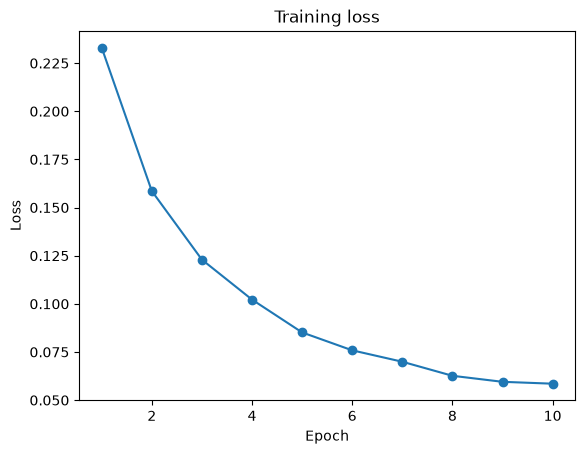

In [26]:
   plt.plot(range(1, 11), losses, marker="o")
   plt.xlabel("Epoch")
   plt.ylabel("Loss")
   plt.title("Training loss")
   plt.show()

In [29]:
train_acc = accuracy(X_train_flat, y_train, W1, b1, W2, b2)
test_acc = accuracy(X_test_flat, y_test, W1, b1, W2, b2)
print(f"Train: {train_acc:.2%}, Test: {test_acc:.2%}")

Train: 98.29%, Test: 97.24%


In [30]:
import os
os.makedirs("images", exist_ok=True)

Wrong: 276 out of 10000


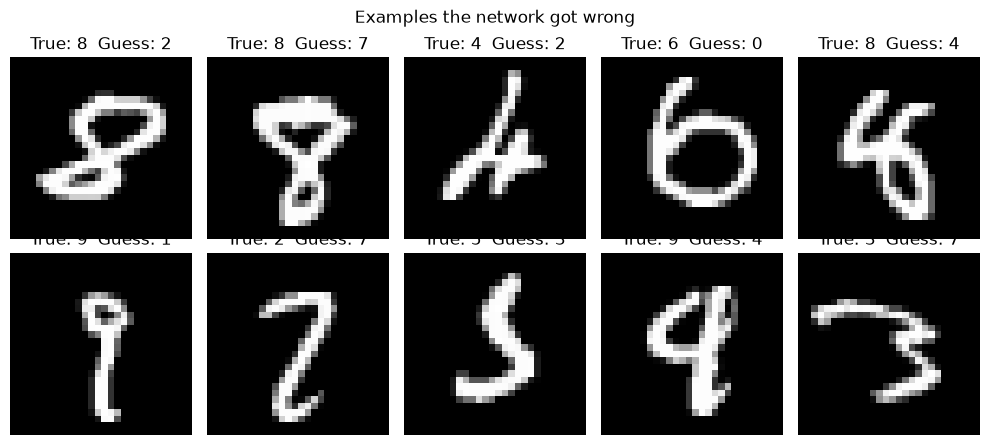

In [31]:
# Get predictions for all test images
_, _, A2_test = forward(X_test_flat, W1, b1, W2, b2)
predictions = A2_test.argmax(axis=1)

# Find the ones it got wrong
wrong = np.where(predictions != y_test)[0]
print(f"Wrong: {len(wrong)} out of {len(y_test)}")

# Show the first 10 mistakes
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, i in zip(axes.flat, wrong[:10]):
    ax.imshow(X_test[i], cmap="gray")
    ax.set_title(f"True: {y_test[i]}  Guess: {predictions[i]}")
    ax.axis("off")

plt.suptitle("Examples the network got wrong")
plt.tight_layout()
plt.savefig("images/mistakes.png", dpi=150)
plt.show()

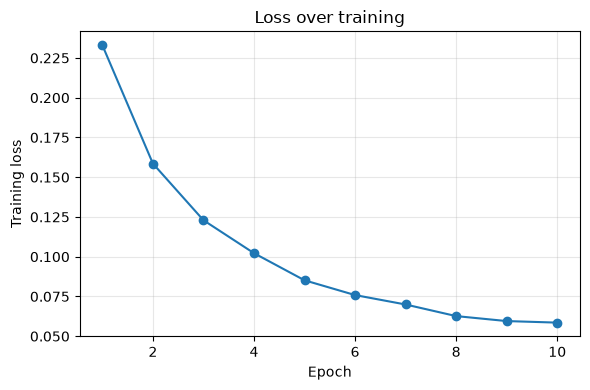

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Loss over training")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/loss.png", dpi=150)
plt.show()